In [3]:
import math
import os
import time
import sys

sys.path.append(os.path.abspath("conditional-flow-matching"))

import matplotlib.pyplot as plt
import numpy as np
import ot as pot
import torch
import torchdyn
from torchdyn.core import NeuralODE
from torchdyn.datasets import generate_moons

from torchcfm.conditional_flow_matching import *
from torchcfm.models.models import *
from torchcfm.utils import *

In [4]:
def sample_quarter(size, i, sigma=0.05):
    f = lambda x: (np.cos(x), np.sin(x))
    z = np.stack(f(np.pi/2 * i + np.pi/2 * np.random.uniform(size=size)), axis = 1)
    ep = sigma * np.random.normal(size=(size, 2))
    return torch.from_numpy(z + ep).float()

In [5]:
%%time

sigma = 0.1
dim = 2
batch_size = 256
model = MLP(dim=dim, time_varying=True)
optimizer = torch.optim.Adam(model.parameters())
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma)
# FM = ConditionalFlowMatcher(sigma=sigma)

losses = []
start = time.time()
for k in range(20000):
    optimizer.zero_grad()

    x0 = sample_quarter(batch_size, 0)
    x1 = sample_quarter(batch_size, 1)

    t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)

    vt = model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (k + 1) % 5000 == 0:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end
        node = NeuralODE(
            torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
        )
        with torch.no_grad():
            traj = node.trajectory(
                sample_quarter(1024, 0),
                t_span=torch.linspace(0, 1, 100),
            )

            print(traj.shape)
            break
            
            plot_trajectories(traj.cpu().numpy())

5000: loss 0.014 time 23.82
torch.Size([100, 1024, 2])
CPU times: user 4min 32s, sys: 170 ms, total: 4min 32s
Wall time: 24 s


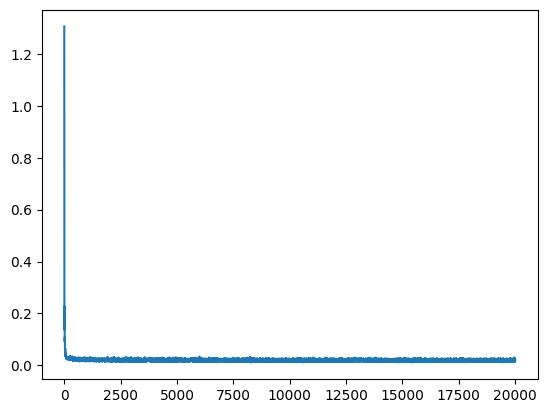

In [4]:
plt.plot(losses)